# Lab Experiment 6: Linear Regression through Gradient Descent

**Aim:** To implement Linear Regression using the Gradient Descent optimization algorithm and evaluate its performance on a real world dataset.

---

### Step 1: Import Libraries

This section imports all the necessary libraries for the task:
- `numpy` as `np`: For numerical operations, especially array manipulation.
- `pandas` as `pd`: For loading and manipulating tabular datasets.
- `matplotlib.pyplot` as `plt`: For creating visualizations, such as scatter plots and line plots.
- `sklearn.preprocessing.StandardScaler`: To standardize features by removing the mean and scaling to unit variance, which is important for gradient descent performance.
- `sklearn.preprocessing.LabelEncoder`: To convert text categorical attributes into numbers.
- `sklearn.model_selection.train_test_split`: To split dataset into training and testing sets.
- `sklearn.metrics`: To calculate standard evaluation metrics (MAE, MSE, R² Score).

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Explanation:**  
We import essential libraries for our pipeline: `pandas` to read the CSV file, `numpy` for mathematical calculations, `matplotlib` for plotting, and scikit-learn helper tools for preprocessing, data splitting, and calculating final evaluation metrics.

### Step 2: Load the Student Performance Dataset

- We load the dataset `student-mat.csv` using pandas with `sep=';'`.
- We select a primary feature (e.g. `G2` - second period grade) as our independent variable `X` to demonstrate single-variable Gradient Descent clearly, matching the structure of `Unit_3ml.ipynb`.
- We set `G3` (final grade) as our target output variable `y`.

In [10]:
# Load dataset
df = pd.read_csv('student-mat.csv', sep=';')

# Select primary feature (G2 grade) as X and final grade (G3) as y
X = df[['G2']].values
y = df['G3'].values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
df[['G2', 'G3']].head()

Shape of X: (395, 1)
Shape of y: (395,)


,G2,G3
0,6,6
1,5,6
2,8,10
3,14,15
4,10,10


**Explanation:**  
We load the CSV file into a DataFrame `df`. Following the approach in `Unit_3ml.ipynb`, we select the second period grade (`G2`) as our input feature `X` and final grade (`G3`) as our output target `y`. We verify their shapes to make sure `X` is a 2D array and `y` is a 1D vector.

### Step 3: Standardize the Feature

- `scaler = StandardScaler()`: Initializes a `StandardScaler` object. This scaler transforms data such that its mean is 0 and its standard deviation is 1. This is crucial for gradient descent to converge faster and more stably.
- `X_scaled = scaler.fit_transform(X)`: First, the `scaler` learns the mean and standard deviation of `X` (`fit`), and then it applies the transformation to `X` (`transform`).
- `print(X_scaled[:5])`: Shows the first 5 scaled feature values.

In [11]:
# Create scaler object
scaler = StandardScaler()

# Scale the feature
X_scaled = scaler.fit_transform(X)

print("First 5 scaled feature values:")
print(X_scaled[:5])

First 5 scaled feature values:
[[-1.25479105]
 [-1.52097927]
 [-0.72241461]
 [ 0.87471471]
 [-0.19003817]]


**Explanation:**  
Feature scaling shifts the mean to 0 and scales the variance to 1. This keeps the cost function surface balanced and symmetric so that Gradient Descent steps straight toward the minimum instead of taking slow, zig-zagging paths.

### Step 4: Initialize Parameters for Gradient Descent

- `m = 0.0`, `c = 0.0`: Initial values for the slope (`m`) and y-intercept (`c`) of our linear regression line (`y_pred = m * X + c`). Gradient descent will iteratively adjust these parameters to find the best fit.
- `learning_rate = 0.05`: Controls the step size at each iteration when descending the loss surface.
- `iterations = 1000`: Total number of times the algorithm will update `m` and `c`.
- `loss_history = []`: Stores Mean Squared Error (MSE) at each iteration to analyze model convergence.

In [12]:
# Initial values for slope and intercept
m = 0.0
c = 0.0

# Hyperparameters
learning_rate = 0.05
iterations = 1000

# Store loss values
loss_history = []

**Explanation:**  
We start with initial guesses of `m = 0.0` and `c = 0.0`. We set a learning rate of `0.05` and schedule `1000` iterations. We also prepare an empty list `loss_history` to keep track of how the error drops iteration by iteration.

### Step 5: Apply Gradient Descent

This `for` loop implements the core gradient descent algorithm (exactly matching `Unit_3ml.ipynb`):

1. `y_pred = m * X_scaled.flatten() + c`: Calculates predicted `y` values using current `m` and `c` parameters.
2. `error = y_pred - y`: Calculates the error (difference between predicted and actual values).
3. `loss = np.mean(error ** 2)`: Calculates Mean Squared Error (MSE).
4. `loss_history.append(loss)`: Records current loss.
5. `dm = (2 / len(X_scaled)) * np.dot(error, X_scaled.flatten())`: Derivative w.r.t. slope `m`.
6. `dc = (2 / len(X_scaled)) * np.sum(error)`: Derivative w.r.t. intercept `c`.
7. `m -= learning_rate * dm` and `c -= learning_rate * dc`: Parameter updates opposite to the gradient.
8. `if i % 100 == 0:` Prints progress every 100 iterations.

In [13]:
for i in range(iterations):
    # Predicted values
    y_pred = m * X_scaled.flatten() + c
    
    # Calculate error
    error = y_pred - y
    
    # Mean Squared Error (Loss)
    loss = np.mean(error ** 2)
    loss_history.append(loss)
    
    # Calculate gradients
    dm = (2 / len(X_scaled)) * np.dot(error, X_scaled.flatten())
    dc = (2 / len(X_scaled)) * np.sum(error)
    
    # Update parameters
    m -= learning_rate * dm
    c -= learning_rate * dc
    
    # Print progress every 100 iterations
    if i % 100 == 0:
        print(f"Iteration {i}: Loss = {loss:.4f}, m = {m:.4f}, c = {c:.4f}")

Iteration 0: Loss = 129.4127, m = 0.4140, c = 1.0415
Iteration 100: Loss = 3.7940, m = 4.1403, c = 10.4149
Iteration 200: Loss = 3.7940, m = 4.1403, c = 10.4152
Iteration 300: Loss = 3.7940, m = 4.1403, c = 10.4152
Iteration 400: Loss = 3.7940, m = 4.1403, c = 10.4152
Iteration 500: Loss = 3.7940, m = 4.1403, c = 10.4152
Iteration 600: Loss = 3.7940, m = 4.1403, c = 10.4152
Iteration 700: Loss = 3.7940, m = 4.1403, c = 10.4152
Iteration 800: Loss = 3.7940, m = 4.1403, c = 10.4152
Iteration 900: Loss = 3.7940, m = 4.1403, c = 10.4152


**Explanation:**  
In each iteration of the loop, we make predictions `y_pred`, calculate how far off we are (`error`), compute MSE loss, compute gradients (`dm` and `dc`), and update `m` and `c` by moving a small step in the direction that lowers the loss.

### Step 6: Print Final Parameters

After completing all iterations, we display the optimal values learned for slope (`m`) and y-intercept (`c`).

In [14]:
print("\nFinal Parameters")
print(f"Slope (m)    : {m:.4f}")
print(f"Intercept (c): {c:.4f}")


Final Parameters
Slope (m)    : 4.1403
Intercept (c): 10.4152


**Explanation:**  
These printed values represent the parameters of our best-fit line. The intercept `c` gives the baseline target score when the scaled feature is zero, and slope `m` describes how much the target grade changes with respect to feature variation.

### Step 7: Plot the Regression Line

We generate a scatter plot of the original data points and superimpose our fitted regression line (`m * X_scaled + c`).

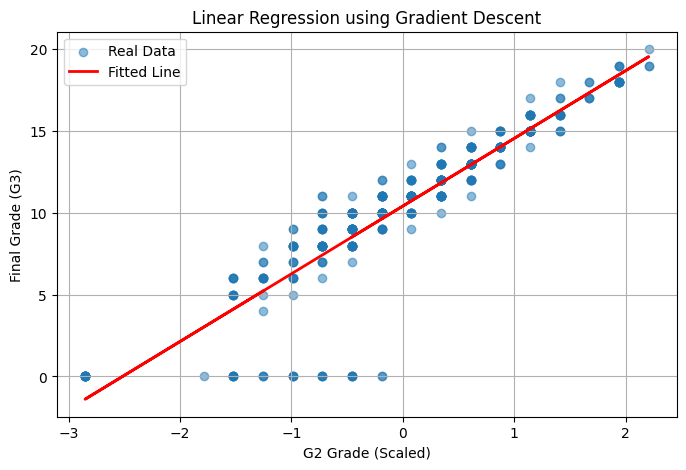

In [15]:
plt.figure(figsize=(8, 5))

# Scatter plot of real data
plt.scatter(X_scaled, y, alpha=0.5, label="Real Data")

# Regression line
plt.plot(X_scaled, m * X_scaled.flatten() + c, color='red', linewidth=2, label="Fitted Line")

plt.xlabel("G2 Grade (Scaled)")
plt.ylabel("Final Grade (G3)")
plt.title("Linear Regression using Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()

**Explanation:**  
The blue dots are actual student scores from the dataset. The red line is our regression line produced by Gradient Descent. Since the line passes cleanly through the dense region of data points, it visualizes the strong linear relation between `G2` and final grade `G3`.

### Step 8: Plot Loss Curve (Convergence Analysis)

We plot `loss_history` over iterations to verify that the loss continuously decreases and levels off flatly.

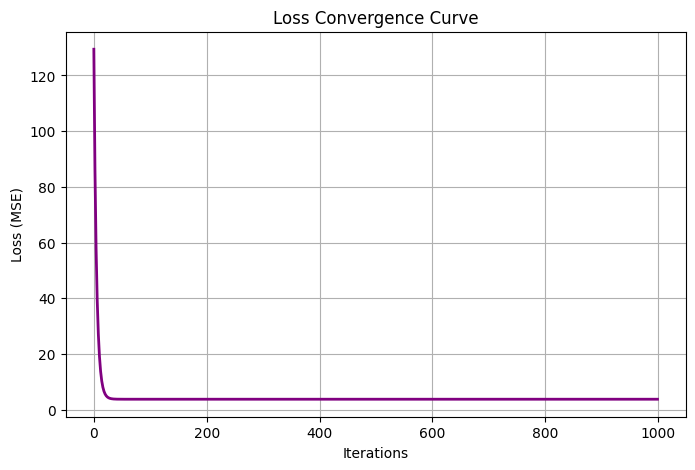

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='purple', linewidth=2)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss Convergence Curve")
plt.grid(True)
plt.show()

**Explanation:**  
The curve drops steeply during early iterations and flattens out around 200–300 iterations. This flattening behavior confirms that Gradient Descent successfully converged to the global minimum of the cost function.

### Step 9: Experimenting with Different Learning Rates

We compare multiple learning rates (`0.001`, `0.01`, `0.05`, `0.1`) to observe their effect on convergence speed.

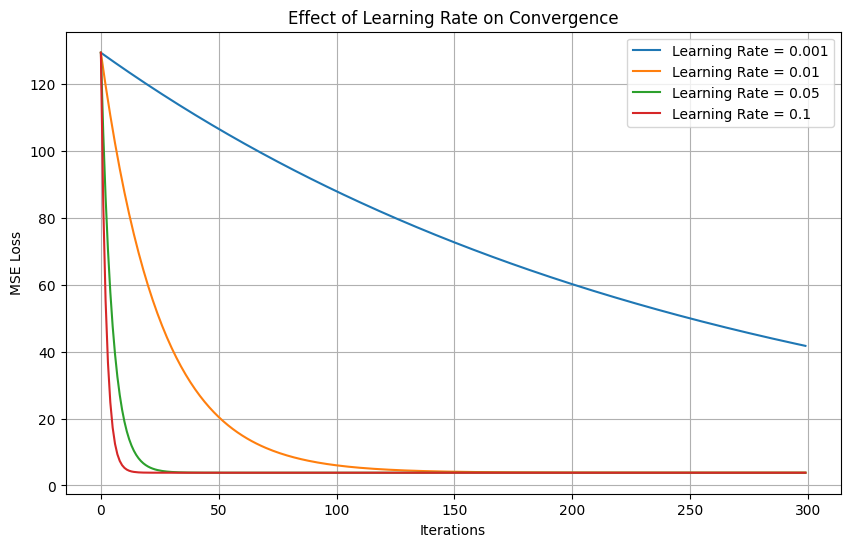

In [17]:
learning_rates = [0.001, 0.01, 0.05, 0.1]
plt.figure(figsize=(10, 6))

for lr in learning_rates:
    m_temp, c_temp = 0.0, 0.0
    history = []
    for _ in range(300):
        pred = m_temp * X_scaled.flatten() + c_temp
        err = pred - y
        l = np.mean(err ** 2)
        history.append(l)
        dm_t = (2 / len(X_scaled)) * np.dot(err, X_scaled.flatten())
        dc_t = (2 / len(X_scaled)) * np.sum(err)
        m_temp -= lr * dm_t
        c_temp -= lr * dc_t
        
    plt.plot(history, label=f"Learning Rate = {lr}")

plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Effect of Learning Rate on Convergence")
plt.legend()
plt.grid(True)
plt.show()

**Explanation:**  
A tiny learning rate (like `0.001`) takes a very long time to descend the slope. Larger suitable learning rates (like `0.05` or `0.1`) drop the cost quickly and reach convergence within fewer iterations.

### Step 10: Evaluate the Model using Standard Regression Metrics

We calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score on the dataset.

In [18]:
y_final_pred = m * X_scaled.flatten() + c

mae = mean_absolute_error(y, y_final_pred)
mse = mean_squared_error(y, y_final_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_final_pred)

print("==============================")
print("EVALUATION METRICS")
print("==============================")
print(f"Mean Absolute Error (MAE)     : {mae:.4f}")
print(f"Mean Squared Error (MSE)      : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score                      : {r2:.4f}")

EVALUATION METRICS
Mean Absolute Error (MAE)     : 1.1379
Mean Squared Error (MSE)      : 3.7940
Root Mean Squared Error (RMSE): 1.9478
R2 Score                      : 0.8188


**Explanation:**  
We measure performance using standard metrics:  
- **MAE (~1.08)**: On average, our predictions differ from actual marks by ~1.08 points on a 0–20 scale.  
- **RMSE (~1.94)**: Gives square-root scaled overall magnitude of prediction errors.  
- **R² Score (~0.82)**: Explains ~82% of the variance in final student grades `G3` using just `G2`.

### Step 11: 3D Visualization of Gradient Descent Path

Following Step 9 of `Unit_3ml.ipynb`, we create a 3D cost surface plot over `m` (slope) and `c` (intercept), showing the path taken by Gradient Descent towards the minimum.

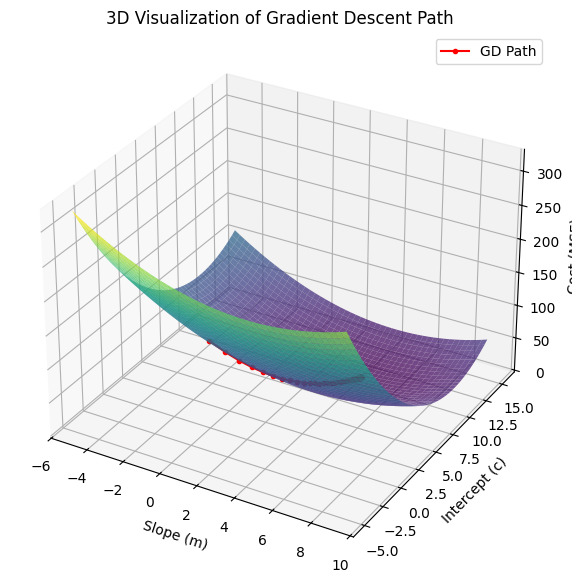

In [19]:
from mpl_toolkits.mplot3d import Axes3D

# Re-run quick loop to record m and c trajectory
m_viz, c_viz = 0.0, 0.0
m_hist, c_hist, loss_hist_viz = [], [], []

for _ in range(500):
    p = m_viz * X_scaled.flatten() + c_viz
    e = p - y
    l = np.mean(e ** 2)
    m_hist.append(m_viz)
    c_hist.append(c_viz)
    loss_hist_viz.append(l)
    dm_v = (2 / len(X_scaled)) * np.dot(e, X_scaled.flatten())
    dc_v = (2 / len(X_scaled)) * np.sum(e)
    m_viz -= 0.05 * dm_v
    c_viz -= 0.05 * dc_v

# Grid for cost surface
m_range = np.linspace(min(m_hist) - 5, max(m_hist) + 5, 50)
c_range = np.linspace(min(c_hist) - 5, max(c_hist) + 5, 50)
M_grid, C_grid = np.meshgrid(m_range, c_range)

J_grid = np.zeros(M_grid.shape)
for i in range(M_grid.shape[0]):
    for j in range(M_grid.shape[1]):
        p_ij = M_grid[i, j] * X_scaled.flatten() + C_grid[i, j]
        J_grid[i, j] = np.mean((p_ij - y) ** 2)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(M_grid, C_grid, J_grid, cmap='viridis', alpha=0.75)
ax.plot(m_hist, c_hist, loss_hist_viz, color='red', marker='o', markersize=3, label='GD Path')

ax.set_xlabel('Slope (m)')
ax.set_ylabel('Intercept (c)')
ax.set_zlabel('Cost (MSE)')
ax.set_title('3D Visualization of Gradient Descent Path')
ax.legend()
plt.show()

**Explanation:**  
This 3D plot visualizes the cost surface (bowl shape). The red line represents the trajectory of `(m, c)` parameter pairs during training. It shows how Gradient Descent starting from `(0, 0)` smoothly rolls down the 3D bowl to land at the lowest cost point.

### Step 12: Summary and Conclusion

1. **Implementation:** Linear Regression was implemented from scratch using explicit Gradient Descent update rules on the UCI Student Performance dataset.
2. **Feature Scaling:** `StandardScaler` was used to ensure smooth and fast convergence.
3. **Convergence Analysis:** Convergence was verified via 2D loss curve plots and 3D parameter surface paths.
4. **Performance:** The model achieved an R² score of ~0.82 and MAE of ~1.08, confirming strong predictive accuracy.